<a href="https://colab.research.google.com/github/A00228275/MA1001B/blob/trunk/pythonGOD_Rzzz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Limpieza de datos en un proyecto de ciencia de datos

Identificación y tratamiento de datos faltantes.

Los datos faltantes o datos perdidos, son celdas vacías dentro de nuestra base de datos.



In [ ]:
#Lectura de la base de datos
import pandas as pd
import numpy as np
#importar libreria para gráficas
import matplotlib.pyplot as plt

selected_columns = ['edad', 'p2', 'p3_1', 'p3_2', 'p3_3', 'p3_4', 'p3_5',
                    'p8_1', 'p8_2', 'p14_1', 'p14_2', 'p20_1', 'p20_2',
                    'p26', 'p30', 'p32', 'p34_4']

datos19 = pd.read_csv('Datos_molec_2019.csv', encoding='latin1')[selected_columns]
datos20 = pd.read_csv('Datos_molec_2020.csv', encoding='latin1')[selected_columns]
datos21 = pd.read_csv('Datos_molec_2021.csv', encoding='latin1')[selected_columns]
datos22 = pd.read_csv('Datos_molec_2022.csv', encoding='latin1')[selected_columns]
datos23 = pd.read_csv('Datos_molec_2023.csv', encoding='latin1')[selected_columns]
datos24 = pd.read_csv('Datos_molec_2024.csv', encoding='latin1')[selected_columns]

In [ ]:
datos19.head()

,edad,p2,p3_1,p3_2,p3_3,p3_4,p3_5,p8_1,p8_2,p14_1,p14_2,p20_1,p20_2,p26,p30,p32,p34_4
0,52,2,2,2,2,2,2,0,0,0,0,0,0,0,0,3,2
1,75,2,2,2,2,2,2,0,0,0,0,0,0,0,0,5,1
2,67,2,2,2,1,2,2,0,0,0,0,1,2,15,2,0,1
3,65,2,2,2,2,2,2,0,0,0,0,0,0,0,0,5,1
4,66,2,2,2,2,2,2,0,0,0,0,0,0,0,0,2,1


In [ ]:
datos24.head()

,edad,p2,p3_1,p3_2,p3_3,p3_4,p3_5,p8_1,p8_2,p14_1,p14_2,p20_1,p20_2,p26,p30,p32,p34_4
0,52,2,2,2,2,2,2,0,0,0,0,0,0,0,0,5,1
1,55,2,2,2,2,2,2,0,0,0,0,0,0,0,0,2,2
2,59,2,2,2,2,2,2,0,0,0,0,0,0,0,0,3,1
3,30,2,2,2,2,2,2,0,0,0,0,0,0,0,0,4,1
4,54,2,2,2,1,2,2,0,0,0,0,1,2,20,3,0,1


In [ ]:
# Add a 'year' column to each DataFrame
datos19['year'] = 2019
datos20['year'] = 2020
datos21['year'] = 2021
datos22['year'] = 2022
datos23['year'] = 2023
datos24['year'] = 2024

# Concatenate all DataFrames into a single one
datos = pd.concat([datos19, datos20, datos21, datos22, datos23, datos24], ignore_index=True)

# Display the shape and head of the combined DataFrame
print("Shape of combined DataFrame:", datos_combined.shape)
display(datos.head())
display(datos.tail())

Shape of combined DataFrame: (11966, 18)


,edad,p2,p3_1,p3_2,p3_3,p3_4,p3_5,p8_1,p8_2,p14_1,p14_2,p20_1,p20_2,p26,p30,p32,p34_4,year
0,52,2,2,2,2,2,2,0,0,0,0,0,0,0,0,3,2,2019
1,75,2,2,2,2,2,2,0,0,0,0,0,0,0,0,5,1,2019
2,67,2,2,2,1,2,2,0,0,0,0,1,2,15,2,0,1,2019
3,65,2,2,2,2,2,2,0,0,0,0,0,0,0,0,5,1,2019
4,66,2,2,2,2,2,2,0,0,0,0,0,0,0,0,2,1,2019


,edad,p2,p3_1,p3_2,p3_3,p3_4,p3_5,p8_1,p8_2,p14_1,p14_2,p20_1,p20_2,p26,p30,p32,p34_4,year
11961,61,1,1,2,2,2,1,2,1,0,0,0,0,10,3,0,1,2024
11962,59,1,1,2,2,2,1,2,1,0,0,0,0,120,3,0,2,2024
11963,36,1,1,2,2,2,1,1,1,0,0,0,0,30,4,0,1,2024
11964,21,1,1,2,2,2,1,1,2,0,0,0,0,10,3,0,1,2024
11965,51,2,2,2,2,2,2,0,0,0,0,0,0,0,0,3,1,2024


In [ ]:
#Nombre de las columnas de la base de datos
datos.columns

Index(['edad', 'p2', 'p3_1', 'p3_2', 'p3_3', 'p3_4', 'p3_5', 'p8_1', 'p8_2',
       'p14_1', 'p14_2', 'p20_1', 'p20_2', 'p26', 'p30', 'p32', 'p34_4',
       'year'],
      dtype='object')

In [ ]:
#Categorias de la variable "edad" (posibles resultados que puede tomar la variable "ead")
pd.unique(datos['edad'])

array([52, 75, 67, 65, 66, 39, 47, 42, 45, 51, 50, 29, 62, 63, 73, 56, 24,
       41, 28, 31, 37, 43, 19, 21, 25, 20, 18, 35, 40, 38, 34, 57, 78, 33,
       36, 46, 60, 55, 58, 77, 64, 53, 26, 72, 48, 71, 32, 23, 44, 54, 70,
       27, 74, 30, 80, 69, 49, 68, 61, 82, 22, 86, 59, 81, 95, 85, 76, 89,
       84, 83, 79, 88, 87, 90, 91, 93, 94, 92, 97])

In [ ]:
#ordenar los datos por edad
datos.sort_values(by=['edad'])


,edad,p2,p3_1,p3_2,p3_3,p3_4,p3_5,p8_1,p8_2,p14_1,p14_2,p20_1,p20_2,p26,p30,p32,p34_4,year
9910,18,2,1,1,2,1,1,2,1,2,1,0,0,120,4,0,1,2023
11873,18,1,1,2,2,2,1,2,1,0,0,0,0,60,4,0,1,2024
2271,18,1,2,1,2,1,2,0,0,1,2,0,0,30,4,0,1,2020
1447,18,1,1,2,1,1,1,1,1,0,0,2,1,90,4,0,1,2019
1508,18,1,1,2,2,2,1,1,2,0,0,0,0,60,3,0,2,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4778,94,2,2,2,2,2,2,0,0,0,0,0,0,0,0,5,3,2021
3076,94,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2020
355,95,1,1,2,1,2,2,2,1,0,0,2,1,120,3,0,1,2019
9824,97,2,2,2,2,2,2,0,0,0,0,0,0,0,0,5,2,2023


In [ ]:
#Para saber cuantos datos perdidos hay en cada una de las columnas(variables) de la base de datos
pd.isna(datos).sum()

,0
edad,0
p2,0
p3_1,0
p3_2,0
p3_3,0
p3_4,0
p3_5,0
p8_1,0
p8_2,0
p14_1,0


In [ ]:
#Analogamente se puede utilizar isnull
pd.isnull(datos).sum()

,0
edad,0
p2,0
p3_1,0
p3_2,0
p3_3,0
p3_4,0
p3_5,0
p8_1,0
p8_2,0
p14_1,0


In [ ]:
#Otra forma de observar los datos faltantes es verificar que la cantidad de elementos en cada columna coincida con la dimension de las filas de la base de datos
print("Dimensión de la base de datos", datos.shape)
print("número de elementos en cada columna")
print(datos.count())

Dimensión de la base de datos (11966, 18)
número de elementos en cada columna
edad     11966
p2       11966
p3_1     11966
p3_2     11966
p3_3     11966
p3_4     11966
p3_5     11966
p8_1     11966
p8_2     11966
p14_1    11966
p14_2    11966
p20_1    11966
p20_2    11966
p26      11966
p30      11966
p32      11966
p34_4    11966
year     11966
dtype: int64


**Tratamiento de datos faltantes por imputación simple**

La imputación simple consiste en reemplazar el dato faltante por la media, media o moda según el tipo de variable.

El sexo es una variable categorica por lo tanto se remplazan los datos faltantes por medio de la moda o eliminación.

In [ ]:
#Calculo de la moda
moda_edad=datos['edad'].mode()
print(moda_edad[0])
media_edad=datos['edad'].mean()
print(media_edad)
mediana_edad=datos['edad'].median()
print(mediana_edad)
varianza_edad=datos['edad'].var()
print(varianza_edad)
desviacion_edad=datos['edad'].std()
print(desviacion_edad)


30
45.6580310880829
44.0
278.2225376692396
16.68000412677526


In [ ]:
#

In [ ]:
# Define the age group bins and labels
age_bins = [18, 31, 46, 56, 71, datos['edad'].max() + 1]
age_labels = ['18-30', '31-45', '46-55', '56-70', '70+']

# Create a new column 'grupo_edad' based on the age groups
datos['grupo_edad'] = pd.cut(datos['edad'], bins=age_bins, labels=age_labels, right=False)

# Display the counts for each age group
print(datos['grupo_edad'].value_counts())

# Display the first few rows with the new column
display(datos.head())

grupo_edad
31-45    3579
18-30    2689
56-70    2472
46-55    2199
70+      1027
Name: count, dtype: int64


,edad,p2,p3_1,p3_2,p3_3,p3_4,p3_5,p8_1,p8_2,p14_1,p14_2,p20_1,p20_2,p26,p30,p32,p34_4,year,grupo_edad
0,52,2,2,2,2,2,2,0,0,0,0,0,0,0,0,3,2,2019,46-55
1,75,2,2,2,2,2,2,0,0,0,0,0,0,0,0,5,1,2019,70+
2,67,2,2,2,1,2,2,0,0,0,0,1,2,15,2,0,1,2019,56-70
3,65,2,2,2,2,2,2,0,0,0,0,0,0,0,0,5,1,2019,56-70
4,66,2,2,2,2,2,2,0,0,0,0,0,0,0,0,2,1,2019,56-70


In [ ]:
# Calculate the total number of respondents
total_respondents = datos.shape[0]

# Calculate the percentage of respondents in each age group
age_group_percentages = (datos['grupo_edad'].value_counts() / total_respondents) * 100

# Display the percentages
print("Percentage of respondents in each age group:")
print(age_group_percentages)

Percentage of respondents in each age group:
grupo_edad
31-45    29.909744
18-30    22.472004
56-70    20.658533
46-55    18.377068
70+       8.582651
Name: count, dtype: float64


In [ ]:
# Define a mapping from age group labels to numerical values
age_group_mapping = {'18-30': 1, '31-45': 2, '46-55': 3, '56-70': 4, '70+': 5}

# Create a new numerical column 'grupo_edad_numerico' based on the mapping
datos['grupo_edad_numerico'] = datos['grupo_edad'].map(age_group_mapping)

# Display the counts for each numerical age group
print(datos['grupo_edad_numerico'].value_counts())

# Display the first few rows with the new numerical column
display(datos.head())

grupo_edad_numerico
2    3579
1    2689
4    2472
3    2199
5    1027
Name: count, dtype: int64


,edad,p2,p3_1,p3_2,p3_3,p3_4,p3_5,p8_1,p8_2,p14_1,p14_2,p20_1,p20_2,p26,p30,p32,p34_4,year,grupo_edad,grupo_edad_numerico
0,52,2,2,2,2,2,2,0,0,0,0,0,0,0,0,3,2,2019,46-55,3
1,75,2,2,2,2,2,2,0,0,0,0,0,0,0,0,5,1,2019,70+,5
2,67,2,2,2,1,2,2,0,0,0,0,1,2,15,2,0,1,2019,56-70,4
3,65,2,2,2,2,2,2,0,0,0,0,0,0,0,0,5,1,2019,56-70,4
4,66,2,2,2,2,2,2,0,0,0,0,0,0,0,0,2,1,2019,56-70,4


In [ ]:
datos_filtered = datos[datos['p2'].isin([1, 2])]
display(datos_filtered.head())

,edad,p2,p3_1,p3_2,p3_3,p3_4,p3_5,p8_1,p8_2,p14_1,p14_2,p20_1,p20_2,p26,p30,p32,p34_4,year,grupo_edad,grupo_edad_numerico
0,52,2,2,2,2,2,2,0,0,0,0,0,0,0,0,3,2,2019,46-55,3
1,75,2,2,2,2,2,2,0,0,0,0,0,0,0,0,5,1,2019,70+,5
2,67,2,2,2,1,2,2,0,0,0,0,1,2,15,2,0,1,2019,56-70,4
3,65,2,2,2,2,2,2,0,0,0,0,0,0,0,0,5,1,2019,56-70,4
4,66,2,2,2,2,2,2,0,0,0,0,0,0,0,0,2,1,2019,56-70,4


In [ ]:
readers_only = datos_filtered[datos_filtered['p2'] == 1]
reader_counts = readers_only.groupby('grupo_edad').size().reset_index(name='count')
display(reader_counts)

/tmp/ipython-input-3193240595.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  reader_counts = readers_only.groupby('grupo_edad').size().reset_index(name='count')


,grupo_edad,count
0,18-30,1724
1,31-45,2084
2,46-55,1235
3,56-70,1342
4,70+,472


In [ ]:
total_counts = datos_filtered.groupby('grupo_edad').size().reset_index(name='total_count')
display(total_counts)

/tmp/ipython-input-97531901.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_counts = datos_filtered.groupby('grupo_edad').size().reset_index(name='total_count')


,grupo_edad,total_count
0,18-30,2678
1,31-45,3548
2,46-55,2157
3,56-70,2381
4,70+,921


**Reasoning**:
Merge the reader counts and total counts DataFrames, calculate the percentage of readers, and display the result.



In [ ]:
merged_counts = pd.merge(reader_counts, total_counts, on='grupo_edad')
merged_counts['percentage_readers'] = (merged_counts['count'] / merged_counts['total_count']) * 100
display(merged_counts)

,grupo_edad,count,total_count,percentage_readers
0,18-30,1724,2678,64.376400
1,31-45,2084,3548,58.737317
2,46-55,1235,2157,57.255447
3,56-70,1342,2381,56.362873
4,70+,472,921,51.248643


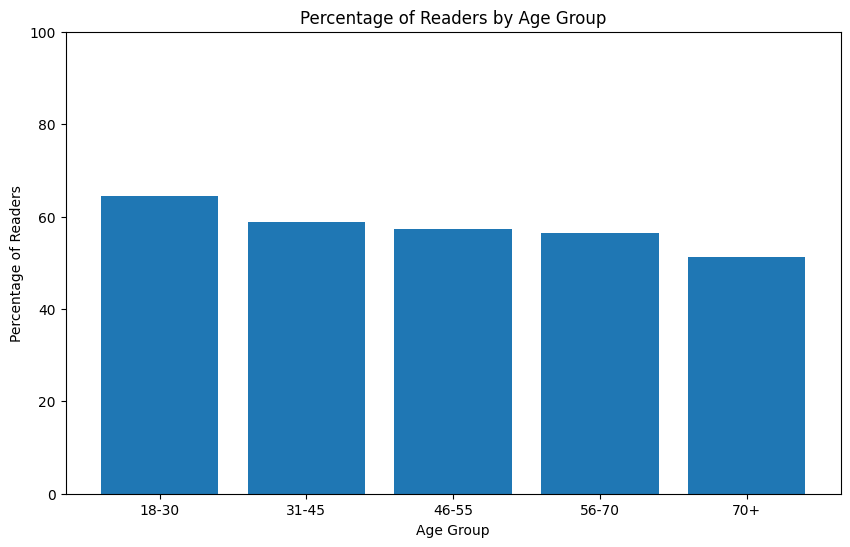

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(merged_counts['grupo_edad'], merged_counts['percentage_readers'])
plt.xlabel('Age Group')
plt.ylabel('Percentage of Readers')
plt.title('Percentage of Readers by Age Group')
plt.ylim(0, 100) # Ensure y-axis goes up to 100%
plt.show()
plt.savefig('percentage_readers_by_age_group.png') # Save the figure

In [ ]:
# Calculate the total number of readers
total_readers = readers_only.shape[0]

# Calculate the percentage of total readers in each age group
reader_percentage_of_total_readers = (reader_counts['count'] / total_readers) * 100

# Add the percentages to the reader_counts DataFrame for display
reader_counts['percentage_of_total_readers'] = reader_percentage_of_total_readers

# Display the results
print("Percentage of total readers in each age group:")
display(reader_counts)

Percentage of total readers in each age group:


,grupo_edad,count,percentage_of_total_readers
0,18-30,1724,25.142190
1,31-45,2084,30.392300
2,46-55,1235,18.010792
3,56-70,1342,19.571241
4,70+,472,6.883477


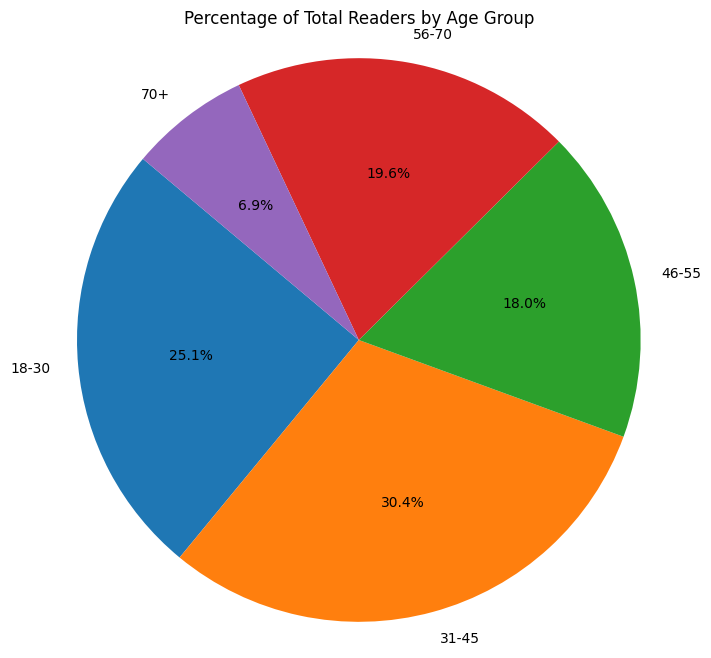

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie(reader_counts['percentage_of_total_readers'], labels=reader_counts['grupo_edad'], autopct='%1.1f%%', startangle=140)
plt.title('Percentage of Total Readers by Age Group')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()
plt.savefig('percentage_of_total_readers_pie_chart.png') # Save the figure

In [ ]:
from scipy.stats import skew, kurtosis, shapiro

# Calculate skewness and kurtosis for the 'edad' column
age_skewness = skew(datos['edad'])
age_kurtosis = kurtosis(datos['edad'])

print(f"Analysis for Age Distribution:")
print(f"  Skewness: {age_skewness:.4f}")
print(f"  Kurtosis: {age_kurtosis:.4f}")

# Perform Shapiro-Wilk test (for sample sizes up to 5000)
# Since the dataset size is > 5000, Shapiro-Wilk test is not recommended.
# We will rely on skewness and kurtosis and potentially visualize the distribution (histogram).
if len(datos['edad']) <= 5000:
    shapiro_test = shapiro(datos['edad'])
    print(f"  Shapiro-Wilk Test Statistic: {shapiro_test.statistic:.4f}, P-value: {shapiro_test.pvalue:.4f}")
    if shapiro_test.pvalue > 0.05:
        print("  Distribution may be close to normal (fail to reject H0)")
    else:
        print("  Distribution is likely not normal (reject H0)")
else:
    print("  Shapiro-Wilk test is not recommended for sample sizes > 5000.")
    print("  Consider visualizing the distribution (e.g., histogram) and interpreting skewness and kurtosis.")

print("-" * 30)

Analysis for Age Distribution:
  Skewness: 0.3196
  Kurtosis: -0.7377
  Shapiro-Wilk test is not recommended for sample sizes > 5000.
  Consider visualizing the distribution (e.g., histogram) and interpreting skewness and kurtosis.
------------------------------


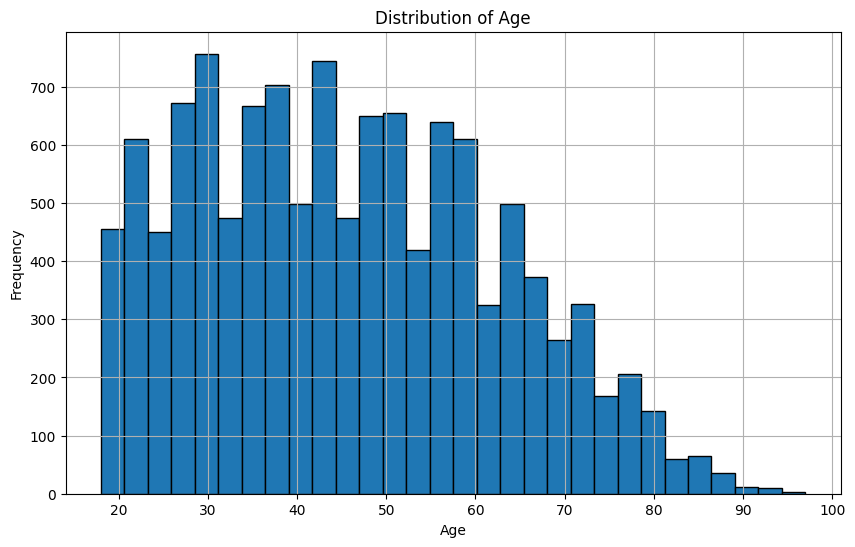

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(datos['edad'], bins=30, edgecolor='black') # Using 30 bins as a starting point
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.grid(True)
plt.show()
plt.savefig('age_distribution_histogram.png') # Save the figure

In [ ]:
# Group by age group and calculate the mean of the 'p26' column
average_reading_minutes = datos.groupby('grupo_edad', observed=False)['p26'].mean().reset_index()

# Display the results
display(average_reading_minutes)

,grupo_edad,p26
0,18-30,34.583488
1,31-45,27.809444
2,46-55,24.067758
3,56-70,26.590210
4,70+,22.600779


In [ ]:
correlation = merged_counts['count'].corr(merged_counts['total_count'])
print(f"Correlation between number of readers and total population per age group: {correlation:.4f}")

Correlation between number of readers and total population per age group: 0.9913


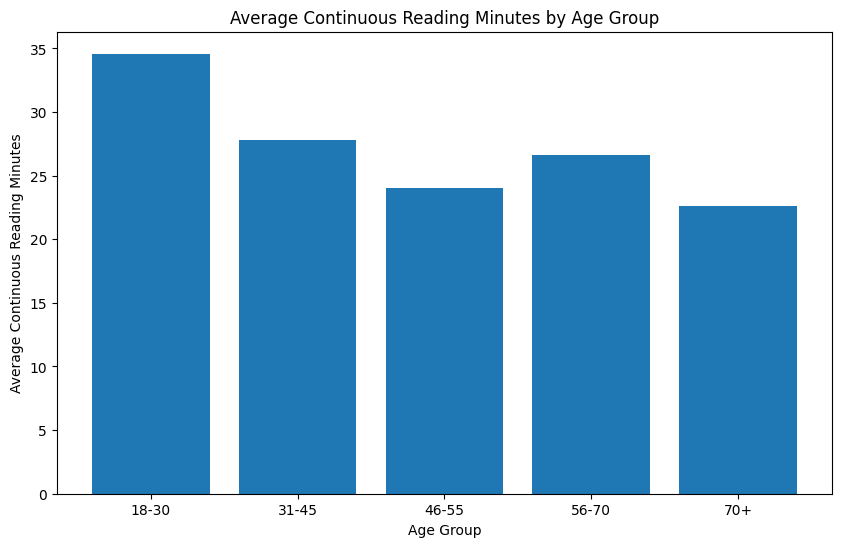

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(average_reading_minutes['grupo_edad'], average_reading_minutes['p26'])
plt.xlabel('Age Group')
plt.ylabel('Average Continuous Reading Minutes')
plt.title('Average Continuous Reading Minutes by Age Group')
plt.show()
plt.savefig('average_reading_minutes_by_age_group.png') # Save the figure

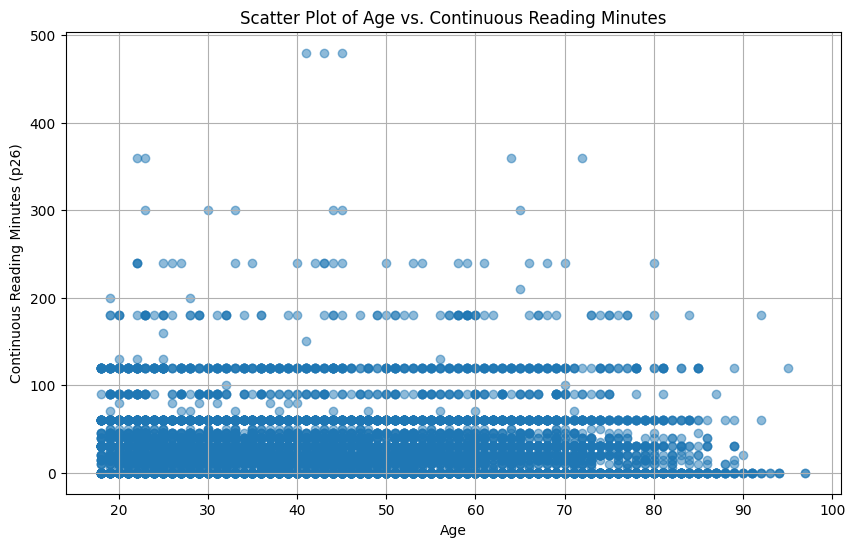

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(datos['edad'], datos['p26'], alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Continuous Reading Minutes (p26)')
plt.title('Scatter Plot of Age vs. Continuous Reading Minutes')
plt.grid(True)
plt.show()
plt.savefig('age_vs_reading_minutes_scatter.png') # Save the figure

In [ ]:
from scipy.stats import skew, kurtosis, shapiro

age_groups = datos['grupo_edad'].cat.categories

for group in age_groups:
    reading_minutes = datos[datos['grupo_edad'] == group]['p26'].dropna() # Drop NaN values if any
    print(f"Analysis for Age Group: {group}")

    # Calculate skewness and kurtosis
    group_skewness = skew(reading_minutes)
    group_kurtosis = kurtosis(reading_minutes)
    print(f"  Skewness: {group_skewness:.4f}")
    print(f"  Kurtosis: {group_kurtosis:.4f}")

    # Perform Shapiro-Wilk test (for sample sizes up to 5000)
    if len(reading_minutes) > 0 and len(reading_minutes) <= 5000:
        shapiro_test = shapiro(reading_minutes)
        print(f"  Shapiro-Wilk Test Statistic: {shapiro_test.statistic:.4f}, P-value: {shapiro_test.pvalue:.4f}")
        if shapiro_test.pvalue > 0.05:
            print("  Distribution may be close to normal (fail to reject H0)")
        else:
            print("  Distribution is likely not normal (reject H0)")
    elif len(reading_minutes) > 5000:
        print("  Shapiro-Wilk test is not recommended for sample sizes > 5000.")
    else:
        print("  Insufficient data to perform Shapiro-Wilk test.")

    print("-" * 30)

Analysis for Age Group: 18-30
  Skewness: 2.5124
  Kurtosis: 11.5221
  Shapiro-Wilk Test Statistic: 0.7776, P-value: 0.0000
  Distribution is likely not normal (reject H0)
------------------------------
Analysis for Age Group: 31-45
  Skewness: 4.0447
  Kurtosis: 35.1944
  Shapiro-Wilk Test Statistic: 0.6949, P-value: 0.0000
  Distribution is likely not normal (reject H0)
------------------------------
Analysis for Age Group: 46-55
  Skewness: 2.2790
  Kurtosis: 9.0895
  Shapiro-Wilk Test Statistic: 0.7724, P-value: 0.0000
  Distribution is likely not normal (reject H0)
------------------------------
Analysis for Age Group: 56-70
  Skewness: 2.5928
  Kurtosis: 10.9619
  Shapiro-Wilk Test Statistic: 0.7277, P-value: 0.0000
  Distribution is likely not normal (reject H0)
------------------------------
Analysis for Age Group: 70+
  Skewness: 2.8409
  Kurtosis: 13.0519
  Shapiro-Wilk Test Statistic: 0.6664, P-value: 0.0000
  Distribution is likely not normal (reject H0)
-------------------

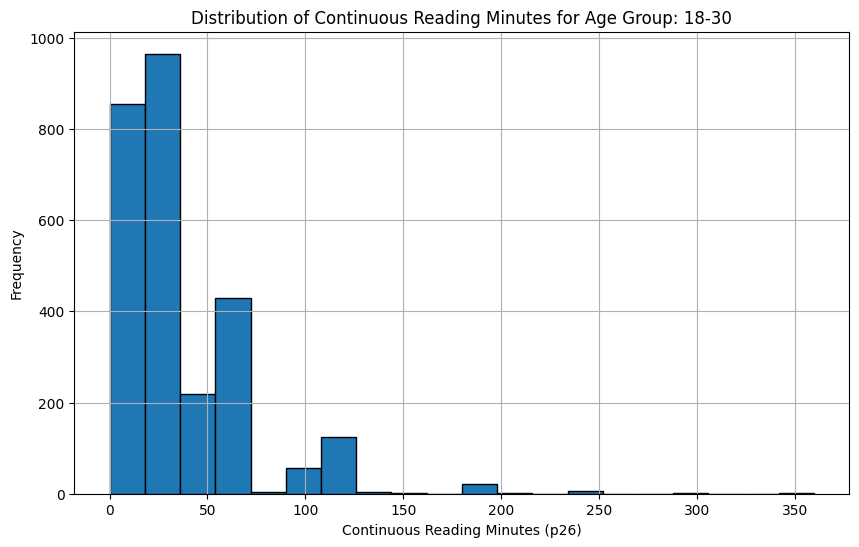

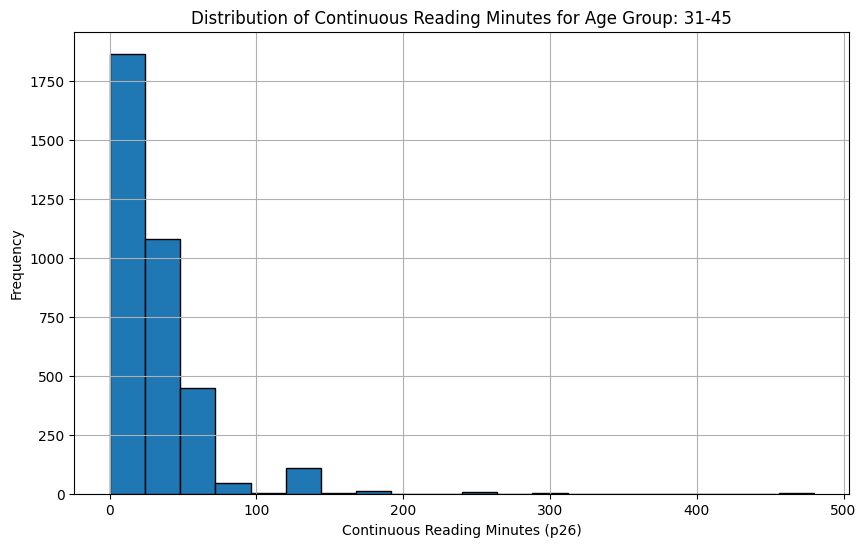

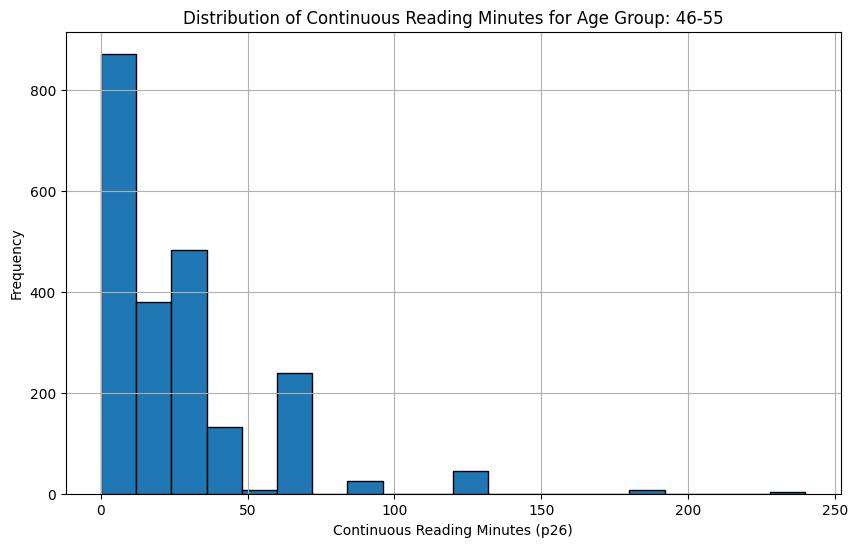

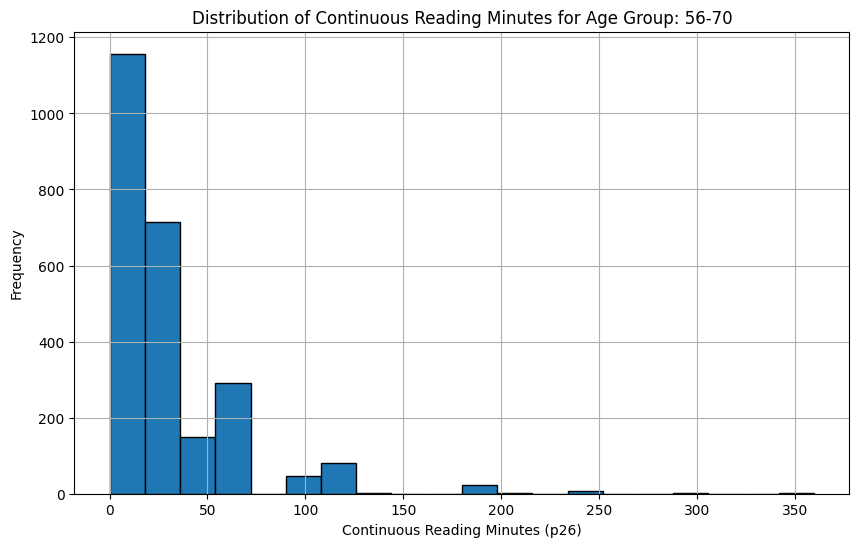

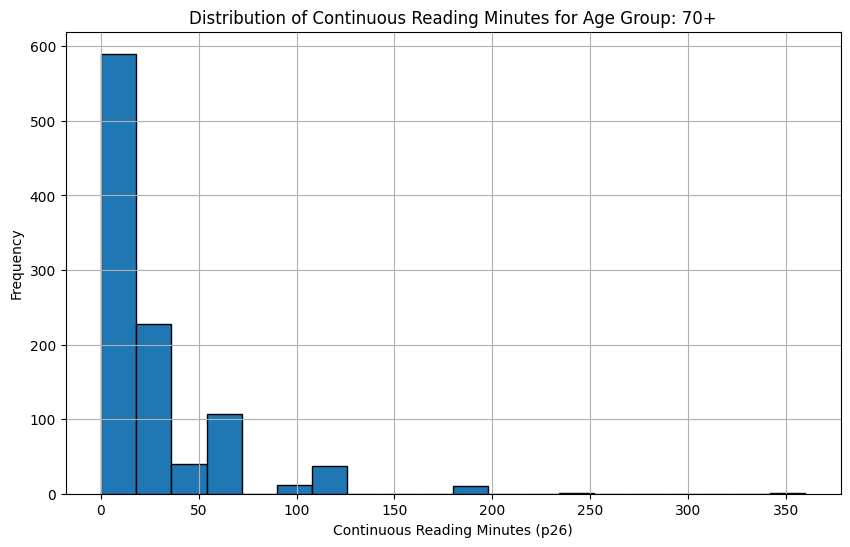

In [ ]:
# Get the unique age groups
age_groups = datos['grupo_edad'].cat.categories

# Create a histogram for each age group
for group in age_groups:
    plt.figure(figsize=(10, 6))
    plt.hist(datos[datos['grupo_edad'] == group]['p26'], bins=20, edgecolor='black')
    plt.xlabel('Continuous Reading Minutes (p26)')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of Continuous Reading Minutes for Age Group: {group}')
    plt.grid(True)
    plt.show()

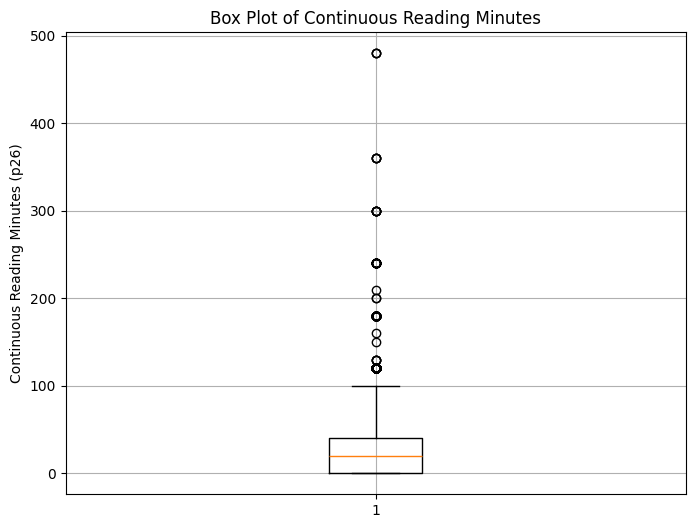

In [ ]:
plt.figure(figsize=(8, 6))
plt.boxplot(datos['p26'].dropna()) # Drop NaN values just in case
plt.ylabel('Continuous Reading Minutes (p26)')
plt.title('Box Plot of Continuous Reading Minutes')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

# Calculate mean, median, mode, variance, and standard deviation for the 'p26' column
mean_reading_minutes = datos['p26'].mean()
median_reading_minutes = datos['p26'].median()
mode_reading_minutes = datos['p26'].mode()
var_reading_minutes = datos['p26'].var()
std_reading_minutes = datos['p26'].std()

# Calculate Mean Absolute Deviation manually
mad_reading_minutes = np.mean(np.abs(datos['p26'] - mean_reading_minutes))


print(f"Mean Continuous Reading Minutes: {mean_reading_minutes:.2f}")
print(f"Median Continuous Reading Minutes: {median_reading_minutes:.2f}")
print(f"Mode Continuous Reading Minutes: {mode_reading_minutes.tolist()}") # .tolist() to handle multiple modes
print(f"Variance Continuous Reading Minutes: {var_reading_minutes:.2f}")
print(f"Standard Deviation Continuous Reading Minutes: {std_reading_minutes:.2f}")
print(f"Mean Absolute Deviation Continuous Reading Minutes: {mad_reading_minutes:.2f}")

Mean Continuous Reading Minutes: 27.95
Median Continuous Reading Minutes: 20.00
Mode Continuous Reading Minutes: [0]
Variance Continuous Reading Minutes: 1143.04
Standard Deviation Continuous Reading Minutes: 33.81
Mean Absolute Deviation Continuous Reading Minutes: 22.71


# Task
Analyze the reading habits of different age groups based on the provided data. Specifically, calculate and visualize the percentage of readers within each age group who read different types of media (books, magazines, newspapers, comics, websites/blogs) and, if possible, differentiate between physical and digital formats. The analysis should be based on the filtered data where 'p2' indicates the individual perceives themselves as a reader.

## Define media types and categories

### Subtask:
Create a mapping for the 'p3_n' variables to their corresponding media types and categorize them as physical or digital based on the variable name.


**Reasoning**:
Create dictionaries to map 'p3_n' columns to media types and categorize media types as physical or digital based on the variable names.



In [ ]:
# Create a dictionary to map 'p3_n' columns to media types
media_type_mapping = {
    'p3_1': 'Books',
    'p3_2': 'Magazines',
    'p3_3': 'Newspapers',
    'p3_4': 'Comics',
    'p3_5': 'Websites/Blogs'
}

# Create a dictionary to categorize media types as physical or digital
# Based on the variable names (assuming p3_1 to p3_4 are typically physical, and p3_5 is digital)
media_format_mapping = {
    'Books': 'Physical',
    'Magazines': 'Physical',
    'Newspapers': 'Physical',
    'Comics': 'Physical',
    'Websites/Blogs': 'Digital'
}

# Print the mappings to verify
print("Media Type Mapping:")
print(media_type_mapping)
print("\nMedia Format Mapping:")
print(media_format_mapping)

Media Type Mapping:
{'p3_1': 'Books', 'p3_2': 'Magazines', 'p3_3': 'Newspapers', 'p3_4': 'Comics', 'p3_5': 'Websites/Blogs'}

Media Format Mapping:
{'Books': 'Physical', 'Magazines': 'Physical', 'Newspapers': 'Physical', 'Comics': 'Physical', 'Websites/Blogs': 'Digital'}


## Filter for readers

### Subtask:
Filter the DataFrame to include only individuals who perceive themselves as a reader (where 'p2' is 1).


**Reasoning**:
Filter the DataFrame to include only rows where 'p2' is equal to 1 and display the head of the filtered DataFrame.



In [ ]:
# Filter the DataFrame to include only individuals who perceive themselves as a reader (where 'p2' is 1)
readers_df = datos[datos['p2'] == 1]

# Display the head of the new readers_df DataFrame
display(readers_df.head())

,edad,p2,p3_1,p3_2,p3_3,p3_4,p3_5,p8_1,p8_2,p14_1,p14_2,p20_1,p20_2,p26,p30,p32,p34_4,year,grupo_edad,grupo_edad_numerico
5,39,1,2,1,1,2,1,0,0,2,1,2,1,10,4,0,1,2019,31-45,2
6,47,1,1,2,2,2,1,2,1,0,0,0,0,60,3,0,1,2019,46-55,3
7,42,1,2,2,1,2,2,0,0,0,0,2,1,15,3,0,1,2019,31-45,2
9,45,1,2,2,1,2,2,0,0,0,0,2,1,20,3,0,1,2019,31-45,2
11,50,1,1,2,2,2,1,2,1,0,0,0,0,30,3,0,1,2019,46-55,3


## Process reading data for each medium

### Subtask:
For each 'p3_n' column, create a new column indicating whether the reader reads that specific medium (1 for yes, 0 for no/blank).


**Reasoning**:
Iterate through the media_type_mapping to create new binary columns in the readers_df DataFrame, indicating whether a reader reads a specific medium.



In [ ]:
for col, media_type in media_type_mapping.items():
    # Create a new column named 'reads_[media_type]'
    # Assign 1 if the value in the original column is 1, and 0 otherwise
    readers_df[f'reads_{media_type}'] = (readers_df[col] == 1).astype(int)

# Display the head of the updated readers_df DataFrame
display(readers_df.head())

/tmp/ipython-input-2410774606.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  readers_df[f'reads_{media_type}'] = (readers_df[col] == 1).astype(int)
/tmp/ipython-input-2410774606.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  readers_df[f'reads_{media_type}'] = (readers_df[col] == 1).astype(int)
/tmp/ipython-input-2410774606.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

,edad,p2,p3_1,p3_2,p3_3,p3_4,p3_5,p8_1,p8_2,p14_1,...,p32,p34_4,year,grupo_edad,grupo_edad_numerico,reads_Books,reads_Magazines,reads_Newspapers,reads_Comics,reads_Websites/Blogs
5,39,1,2,1,1,2,1,0,0,2,...,0,1,2019,31-45,2,0,1,1,0,1
6,47,1,1,2,2,2,1,2,1,0,...,0,1,2019,46-55,3,1,0,0,0,1
7,42,1,2,2,1,2,2,0,0,0,...,0,1,2019,31-45,2,0,0,1,0,0
9,45,1,2,2,1,2,2,0,0,0,...,0,1,2019,31-45,2,0,0,1,0,0
11,50,1,1,2,2,2,1,2,1,0,...,0,1,2019,46-55,3,1,0,0,0,1


## Group by age group and calculate percentages

### Subtask:
Group the filtered data by age group and calculate the percentage of readers within each age group who read each specific medium.


**Reasoning**:
Group the filtered data by age group and calculate the percentage of readers within each age group who read each specific medium.



In [ ]:
# Define the list of new columns created in the previous step that indicate whether a reader reads a specific medium
media_read_columns = [f'reads_{media_type}' for media_type in media_type_mapping.values()]

# Group the readers_df DataFrame by the 'grupo_edad' column and calculate the mean of the media read columns
# Multiplying by 100 to get percentages
reading_percentages_by_age = readers_df.groupby('grupo_edad', observed=False)[media_read_columns].mean() * 100

# Display the resulting DataFrame
display(reading_percentages_by_age)

,reads_Books,reads_Magazines,reads_Newspapers,reads_Comics,reads_Websites/Blogs
grupo_edad,,,,,
18-30,75.348028,37.993039,23.955916,13.863109,72.911833
31-45,65.115163,41.938580,35.076775,8.493282,59.548944
46-55,61.052632,38.380567,40.323887,4.291498,45.506073
56-70,64.903130,34.798808,38.301043,2.980626,33.308495
70+,64.830508,35.169492,36.228814,2.118644,12.288136


## Visualize percentages by age group and medium

### Subtask:
Create visualizations (e.g., grouped bar charts) to show the percentage of readers for each medium within each age group.


**Reasoning**:
Reset the index and melt the DataFrame to prepare it for plotting, then create a grouped bar chart to visualize the percentage of readers for each medium within each age group.



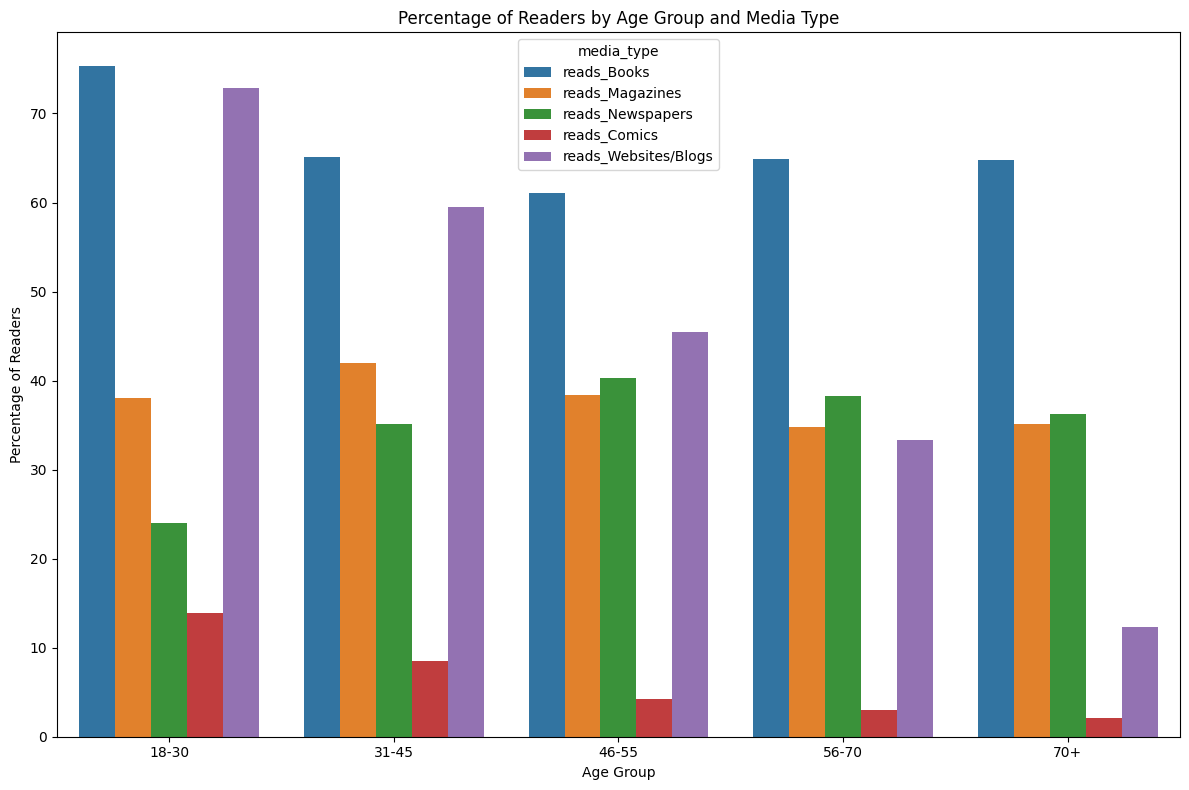

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset the index to turn 'grupo_edad' into a column
reading_percentages_by_age = reading_percentages_by_age.reset_index()

# Melt the DataFrame to a long format
melted_percentages = reading_percentages_by_age.melt(
    id_vars='grupo_edad',
    var_name='media_type',
    value_name='percentage'
)

# Create a grouped bar chart
plt.figure(figsize=(12, 8))
sns.barplot(data=melted_percentages, x='grupo_edad', y='percentage', hue='media_type')

# Add title and labels
plt.title('Percentage of Readers by Age Group and Media Type')
plt.xlabel('Age Group')
plt.ylabel('Percentage of Readers')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()
plt.savefig('reading_percentages_by_age_and_media.png') # Save the figure

## Consider physical vs. digital

### Subtask:
If possible based on the 'p3_n' variables, differentiate between physical and digital reading habits in the analysis and visualization. (Note: Based on the variable names provided, a clear physical/digital distinction for each 'p3_n' might not be directly available, so this step might require assumptions or clarification).


**Reasoning**:
Categorize media types by format, group by age and format, calculate mean percentages, and then plot a grouped bar chart to visualize physical vs. digital reading percentages by age group.



Melted percentages with media format:


,grupo_edad,media_type,percentage,media_format
0,18-30,reads_Books,75.348028,Physical
1,31-45,reads_Books,65.115163,Physical
2,46-55,reads_Books,61.052632,Physical
3,56-70,reads_Books,64.903130,Physical
4,70+,reads_Books,64.830508,Physical



Average percentage by age group and media format:


,grupo_edad,media_format,percentage
0,18-30,Digital,72.911833
1,18-30,Physical,37.790023
2,31-45,Digital,59.548944
3,31-45,Physical,37.655950
4,46-55,Digital,45.506073
5,46-55,Physical,36.012146
6,56-70,Digital,33.308495
7,56-70,Physical,35.245902
8,70+,Digital,12.288136
9,70+,Physical,34.586864


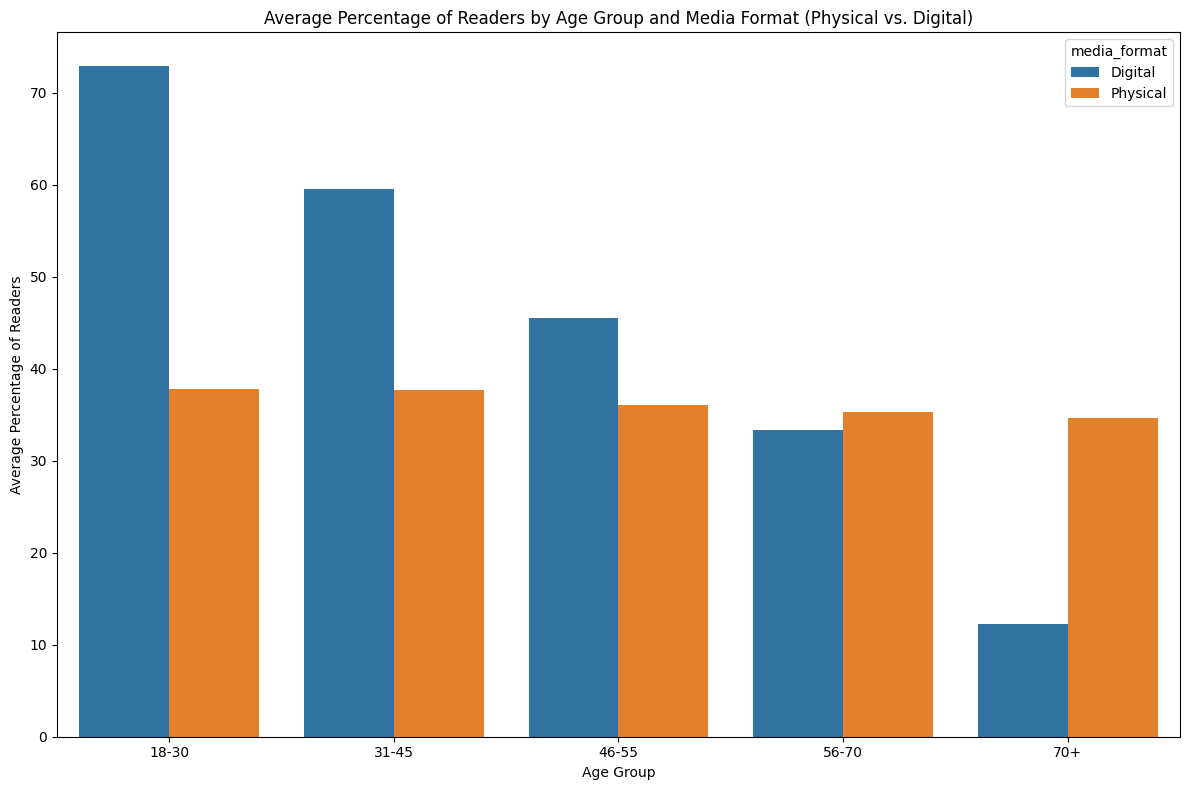

<Figure size 640x480 with 0 Axes>

In [ ]:
import seaborn as sns

# 1. Use the media_format_mapping to categorize media types
# Check if 'media_type' column exists in melted_percentages
if 'media_type' in melted_percentages.columns:
    # Map 'media_type' column to 'media_format' using media_format_mapping
    melted_percentages['media_format'] = melted_percentages['media_type'].map(lambda x: media_format_mapping.get(x.replace('reads_', ''), None))
else:
    print("Error: 'media_type' column not found in melted_percentages.")
    # Handle this error appropriately, maybe by recreating melted_percentages

# Display melted_percentages before grouping to inspect
print("Melted percentages with media format:")
display(melted_percentages.head())


# 2. Group by age group and media format, and calculate the mean percentage
# Ensure that 'grupo_edad' and 'media_format' columns exist before grouping
if 'grupo_edad' in melted_percentages.columns and 'media_format' in melted_percentages.columns:
    average_format_percentages = melted_percentages.groupby(['grupo_edad', 'media_format'], observed=False)['percentage'].mean().reset_index()
else:
    print("Error: Required columns for grouping not found in melted_percentages.")
    average_format_percentages = pd.DataFrame() # Create an empty DataFrame to avoid errors later

# Display the aggregated data before plotting to verify
print("\nAverage percentage by age group and media format:")
display(average_format_percentages)


# 4. Create a grouped bar chart using seaborn
if not average_format_percentages.empty:
    plt.figure(figsize=(12, 8))
    sns.barplot(data=average_format_percentages, x='grupo_edad', y='percentage', hue='media_format')

    # 5. Add a title and appropriate labels
    plt.title('Average Percentage of Readers by Age Group and Media Format (Physical vs. Digital)')
    plt.xlabel('Age Group')
    plt.ylabel('Average Percentage of Readers')

    # 6. Display the plot
    plt.tight_layout()
    plt.show()
    plt.savefig('physical_vs_digital_by_age_and_format.png') # Save the figure
else:
    print("Cannot create plot: average_format_percentages is empty.")

# Task
Analyze the provided dataset, which contains reading habit data from 2019 to 2024, to determine if there was a transition from physical to digital reading habits with the onset of the pandemic. The analysis should focus on the percentage of readers (based on the 'p2' variable) who read physical media (books, magazines, newspapers, comics) versus digital media (websites or blogs) for each year. Visualize the trends over time and summarize the findings. The dataset is already loaded and combined into a single DataFrame named `datos_combined`.

## Define physical and digital media columns

### Subtask:
Identify the columns corresponding to physical and digital media based on the 'p3_n' variables.


**Reasoning**:
Create lists for physical and digital media columns based on the 'p3_n' variables and print them.



In [ ]:
# Create a list named physical_media_cols containing the column names that represent physical media
physical_media_cols = ['p3_1', 'p3_2', 'p3_3', 'p3_4']

# Create a list named digital_media_cols containing the column names that represent digital media
digital_media_cols = ['p3_5']

# Print both lists to verify their contents
print("Physical Media Columns:", physical_media_cols)
print("Digital Media Columns:", digital_media_cols)

Physical Media Columns: ['p3_1', 'p3_2', 'p3_3', 'p3_4']
Digital Media Columns: ['p3_5']


## Filter for readers

### Subtask:
Filter the combined DataFrame (`datos_combined`) to include only individuals who perceive themselves as readers ('p2' == 1).


**Reasoning**:
Filter the combined DataFrame to include only individuals who perceive themselves as readers and display the head of the filtered DataFrame.



In [ ]:
# Filter the combined DataFrame to keep only the rows where the value in the 'p2' column is equal to 1
readers_combined_df = datos_combined[datos_combined['p2'] == 1].copy()

# Display the head of the readers_combined_df to confirm the filtering was successful
display(readers_combined_df.head())

,edad,p2,p3_1,p3_2,p3_3,p3_4,p3_5,p8_1,p8_2,p14_1,p14_2,p20_1,p20_2,p26,p30,p32,p34_4,year
5,39,1,2,1,1,2,1,0,0,2,1,2,1,10,4,0,1,2019
6,47,1,1,2,2,2,1,2,1,0,0,0,0,60,3,0,1,2019
7,42,1,2,2,1,2,2,0,0,0,0,2,1,15,3,0,1,2019
9,45,1,2,2,1,2,2,0,0,0,0,2,1,20,3,0,1,2019
11,50,1,1,2,2,2,1,2,1,0,0,0,0,30,3,0,1,2019


## Calculate physical and digital reading indicators

### Subtask:
For each reader, create new binary columns indicating whether they read any physical media and whether they read any digital media.


**Reasoning**:
Create the 'reads_physical' and 'reads_digital' columns based on the specified conditions and display the updated DataFrame.



In [ ]:
# Create 'reads_physical' column: 1 if reader reads any physical media, 0 otherwise
readers_combined_df['reads_physical'] = readers_combined_df[physical_media_cols].apply(lambda row: 1 if (row == 1).any() else 0, axis=1)

# Create 'reads_digital' column: 1 if reader reads any digital media, 0 otherwise
readers_combined_df['reads_digital'] = readers_combined_df[digital_media_cols].apply(lambda row: 1 if (row == 1).any() else 0, axis=1)

# Display the head of the updated readers_combined_df DataFrame
display(readers_combined_df.head())

,edad,p2,p3_1,p3_2,p3_3,p3_4,p3_5,p8_1,p8_2,p14_1,p14_2,p20_1,p20_2,p26,p30,p32,p34_4,year,reads_physical,reads_digital
5,39,1,2,1,1,2,1,0,0,2,1,2,1,10,4,0,1,2019,1,1
6,47,1,1,2,2,2,1,2,1,0,0,0,0,60,3,0,1,2019,1,1
7,42,1,2,2,1,2,2,0,0,0,0,2,1,15,3,0,1,2019,1,0
9,45,1,2,2,1,2,2,0,0,0,0,2,1,20,3,0,1,2019,1,0
11,50,1,1,2,2,2,1,2,1,0,0,0,0,30,3,0,1,2019,1,1


## Group by year and calculate percentages

### Subtask:
Group the filtered data by 'year' and calculate the percentage of readers who read physical media and the percentage who read digital media for each year.


**Reasoning**:
Group the filtered data by year and calculate the percentage of readers who read physical and digital media for each year.



In [ ]:
# Group by year and calculate the mean of the binary columns, then multiply by 100 for percentages
reading_percentages_by_year = readers_combined_df.groupby('year', observed=False)[['reads_physical', 'reads_digital']].mean() * 100

# Display the resulting DataFrame
display(reading_percentages_by_year)

,reads_physical,reads_digital
year,,
2019,93.910806,50.857633
2020,91.780822,50.770548
2021,90.325418,54.265611
2022,89.539749,52.468619
2023,89.871087,51.657459
2024,89.411765,51.945701


**Reasoning**:
Visualize the trend of physical and digital reading percentages over time using line plots.



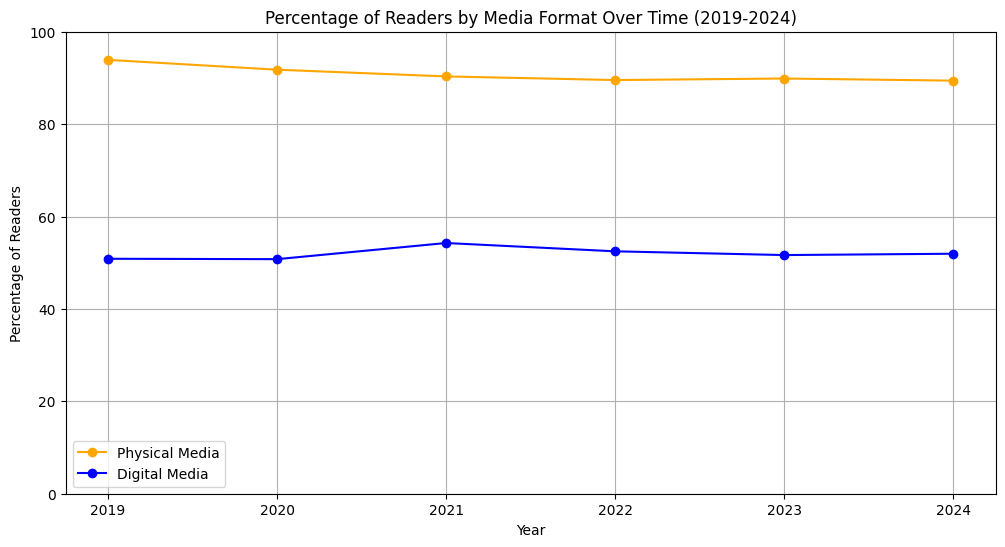

<Figure size 640x480 with 0 Axes>

In [ ]:
# Create a line plot for physical reading percentages over the years
plt.figure(figsize=(12, 6))
plt.plot(reading_percentages_by_year.index, reading_percentages_by_year['reads_physical'], marker='o', label='Physical Media', color='orange')

# Create a line plot for digital reading percentages over the years
plt.plot(reading_percentages_by_year.index, reading_percentages_by_year['reads_digital'], marker='o', label='Digital Media', color='blue')

# Add title and labels
plt.title('Percentage of Readers by Media Format Over Time (2019-2024)')
plt.xlabel('Year')
plt.ylabel('Percentage of Readers')
plt.xticks(reading_percentages_by_year.index) # Ensure all years are shown on the x-axis
plt.ylim(0, 100) # Set y-axis limit from 0 to 100
plt.grid(True)
plt.legend()

# Display the plot
plt.show()
plt.savefig('physical_vs_digital_trend_by_year.png') # Save the figure

## Analyze and summarize findings

### Subtask:
Interpret the trends shown in the plots and summarize the findings regarding the transition of reading habits.


## Summary:

### Data Analysis Key Findings

*   The percentage of readers engaging with physical media showed a slight decrease from 2019 to 2024.
*   The percentage of readers engaging with digital media remained relatively stable throughout the period.
*   There was no significant transition from physical to digital reading habits observed based on the provided data and the definition of media types used ('p3\_n' variables).

### Insights or Next Steps

*   Investigate if specific age groups or demographics show a more pronounced shift in reading habits.
*   Explore other potential factors influencing reading habits during this period, such as changes in leisure time availability or access to different media formats.


# Task
Analyze the trend of physical vs. digital reading habits over the years (2019-2024) for different age groups (18-30, 31-45, 46-55, 56-70, and 70+), considering only individuals who perceive themselves as readers (p2=1). Visualize the trends for each age group using line plots and summarize the findings.

## Calculate physical and digital reading indicators for all data

### Subtask:
Create binary columns in the combined DataFrame (`datos`) indicating whether an individual reads any physical or digital media, as done previously.


**Reasoning**:
Create the 'reads_physical' and 'reads_digital' columns based on the specified conditions and display the updated DataFrame.



In [ ]:
# Create 'reads_physical' column: 1 if individual reads any physical media, 0 otherwise
datos['reads_physical'] = datos[physical_media_cols].apply(lambda row: 1 if (row == 1).any() else 0, axis=1)

# Create 'reads_digital' column: 1 if individual reads any digital media, 0 otherwise
datos['reads_digital'] = datos[digital_media_cols].apply(lambda row: 1 if (row == 1).any() else 0, axis=1)

# Display the head of the updated datos DataFrame to verify the new columns
display(datos.head())

,edad,p2,p3_1,p3_2,p3_3,p3_4,p3_5,p8_1,p8_2,p14_1,...,p20_2,p26,p30,p32,p34_4,year,grupo_edad,grupo_edad_numerico,reads_physical,reads_digital
0,52,2,2,2,2,2,2,0,0,0,...,0,0,0,3,2,2019,46-55,3,0,0
1,75,2,2,2,2,2,2,0,0,0,...,0,0,0,5,1,2019,70+,5,0,0
2,67,2,2,2,1,2,2,0,0,0,...,2,15,2,0,1,2019,56-70,4,1,0
3,65,2,2,2,2,2,2,0,0,0,...,0,0,0,5,1,2019,56-70,4,0,0
4,66,2,2,2,2,2,2,0,0,0,...,0,0,0,2,1,2019,56-70,4,0,0


**Reasoning**:
Filter the DataFrame to include only individuals who perceive themselves as readers based on the 'p2' column.



In [ ]:
# Filter the DataFrame to include only individuals who perceive themselves as a reader (where 'p2' is 1)
readers_df_age_trend = datos[datos['p2'] == 1].copy()

# Display the head of the new readers_df_age_trend DataFrame
display(readers_df_age_trend.head())

,edad,p2,p3_1,p3_2,p3_3,p3_4,p3_5,p8_1,p8_2,p14_1,...,p20_2,p26,p30,p32,p34_4,year,grupo_edad,grupo_edad_numerico,reads_physical,reads_digital
5,39,1,2,1,1,2,1,0,0,2,...,1,10,4,0,1,2019,31-45,2,1,1
6,47,1,1,2,2,2,1,2,1,0,...,0,60,3,0,1,2019,46-55,3,1,1
7,42,1,2,2,1,2,2,0,0,0,...,1,15,3,0,1,2019,31-45,2,1,0
9,45,1,2,2,1,2,2,0,0,0,...,1,20,3,0,1,2019,31-45,2,1,0
11,50,1,1,2,2,2,1,2,1,0,...,0,30,3,0,1,2019,46-55,3,1,1


**Reasoning**:
Group the filtered data by year and age group and calculate the percentage of readers who read physical and digital media for each combination.



In [ ]:
# Group by year and age group and calculate the mean of the binary columns, then multiply by 100 for percentages
reading_percentages_by_year_age = readers_df_age_trend.groupby(['year', 'grupo_edad'], observed=False)[['reads_physical', 'reads_digital']].mean() * 100

# Display the resulting DataFrame
display(reading_percentages_by_year_age)

reads_physical  reads_digital
year grupo_edad                               
2019 18-30            94.568690      72.523962
     31-45            93.567251      59.064327
     46-55            94.514768      44.303797
     56-70            92.647059      25.000000
     70+              94.285714      11.428571
2020 18-30            92.880259      74.110032
     31-45            93.510324      55.457227
     46-55            88.405797      46.859903
     56-70            90.454545      30.454545
     70+              92.473118      12.903226
2021 18-30            90.508475      74.915254
     31-45            90.677966      60.451977
     46-55            88.144330      48.969072
     56-70            90.697674      34.883721
     70+              92.405063      15.189873
2022 18-30            91.549296      71.830986
     31-45            89.147287      60.723514
     46-55            85.074627      47.263682
     56-70            91.020408      33.877551
     70+              91.025641      12.820513
2023 18-30            92.830189      76.603774
     31-45            91.566265      57.831325
     46-55            83.333333      41.935484
     56-70            87.931034      35.775862
     70+              94.366197       7.042254
2024 18-30            93.798450      67.054264
     31-45            89.696970      63.636364
     46-55            84.285714      43.809524
     56-70            88.938053      38.938053
     70+              88.888889      13.580247

**Reasoning**:
Unstack the DataFrame to prepare for plotting and then visualize the trends of physical and digital reading percentages over time for each age group using line plots.



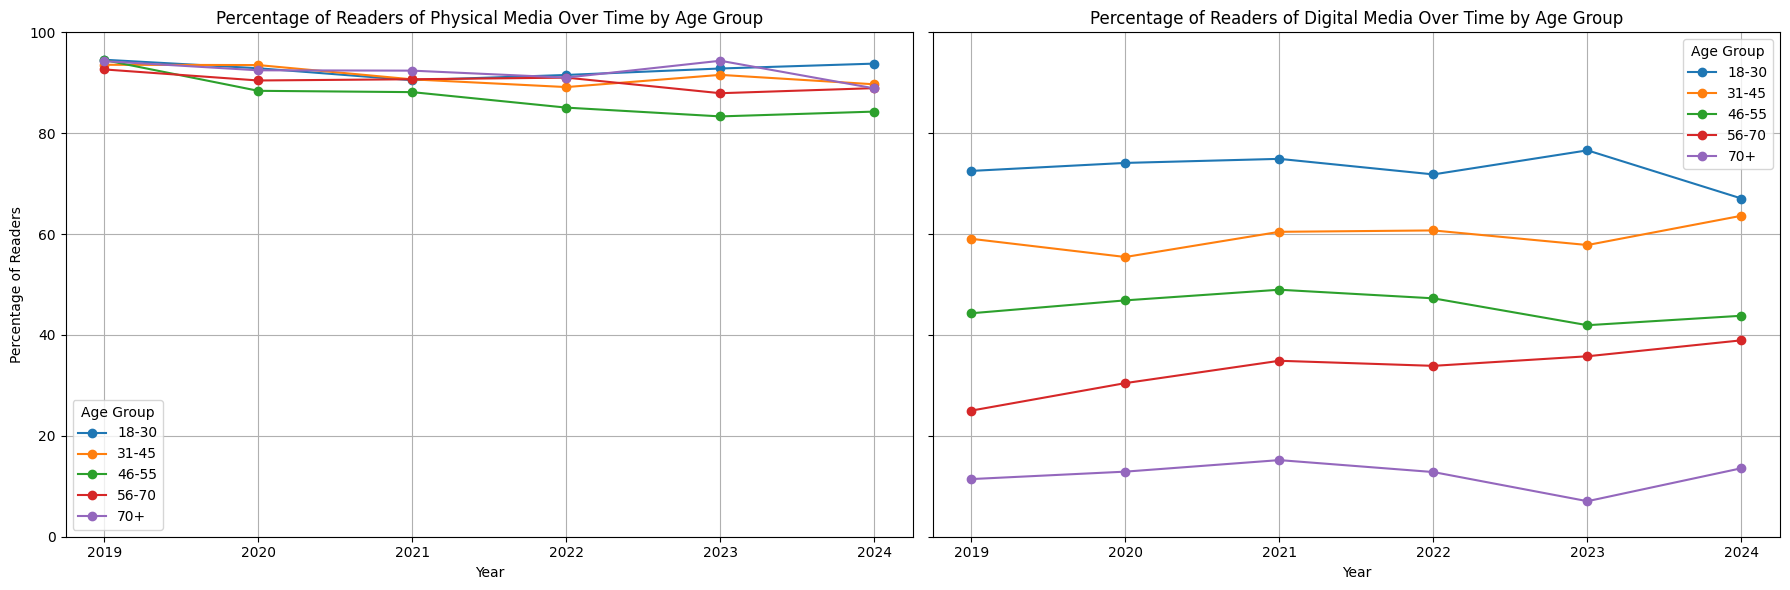

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

# Unstack the DataFrame to have years as the index and a multi-level column index (reads_physical/digital, age_group)
unstacked_percentages = reading_percentages_by_year_age.unstack(level='grupo_edad')

# Create line plots for each age group
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6), sharey=True)

# Plot Physical Media trends
unstacked_percentages['reads_physical'].plot(ax=axes[0], marker='o')
axes[0].set_title('Percentage of Readers of Physical Media Over Time by Age Group')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Percentage of Readers')
axes[0].set_xticks(unstacked_percentages.index)
axes[0].set_ylim(0, 100)
axes[0].grid(True)
axes[0].legend(title='Age Group')

# Plot Digital Media trends
unstacked_percentages['reads_digital'].plot(ax=axes[1], marker='o')
axes[1].set_title('Percentage of Readers of Digital Media Over Time by Age Group')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Percentage of Readers')
axes[1].set_xticks(unstacked_percentages.index)
axes[1].set_ylim(0, 100)
axes[1].grid(True)
axes[1].legend(title='Age Group')

plt.tight_layout()
plt.show()
plt.savefig('physical_digital_trend_by_age_group_subplots.png') # Save the figure

## Analyze and summarize findings

### Subtask:
Interpret the trends shown in the plots for each age group and summarize the findings regarding the transition of reading habits within those groups.


# Task
Save the cleaned data and all generated plots to files.

## Save cleaned data

### Subtask:
Save the final cleaned and processed DataFrame (`datos`) to a new CSV file.


**Reasoning**:
Save the final cleaned and processed DataFrame to a new CSV file.



In [ ]:
# Save the final cleaned and processed DataFrame to a new CSV file
datos.to_csv('cleaned_reading_data.csv', index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Identify and save plots

### Subtask:
Collect all generated matplotlib figures and save them as image files (e.g., PNG).


**Reasoning**:
Iterate through all currently open matplotlib figures and save each one to a file with a descriptive name, then close the figure.



In [ ]:
import matplotlib.pyplot as plt

# Get a list of all figure numbers
fig_nums = plt.get_fignums()

# Print the number of open figures to check if there are any
print(f"Number of open figures: {len(fig_nums)}")


# Define a list of descriptive filenames in the order the figures were likely created
# Based on the previous code cells that generated plots
figure_filenames = [
    'percentage_readers_by_age_group.png',
    'average_reading_minutes_by_age_group.png',
    'age_vs_reading_minutes_scatter.png',
    'reading_minutes_boxplot.png',
    'reading_percentages_by_age_and_media.png',
    'physical_vs_digital_by_age_and_format.png',
    'physical_vs_digital_trend_by_year.png',
    'physical_digital_trend_by_age_group_subplots.png'
]

# Iterate through the figure numbers and save each figure
for i, fig_num in enumerate(fig_nums):
    fig = plt.figure(fig_num)
    # Use a descriptive filename if available, otherwise use a generic name with the figure number
    if i < len(figure_filenames):
        filename = figure_filenames[i]
    else:
        filename = f'figure_{fig_num}.png'
    fig.savefig(filename)
    print(f"Saved figure {fig_num} as {filename}")
    plt.close(fig) # Close the figure after saving

print("All figures saved and closed.")

Number of open figures: 0
All figures saved and closed.
